
The notebook performs a Phase 1 hydro-meteorological network audit for Idaho, integrating multiple observational networks to:
	•	Identify overlaps
	•	Detect redundancies
	•	Quantify gaps
	•	Evaluate integration potential

It focuses on:
	•	Synoptic
	•	SNOTEL (official)
	•	ITD RWIS



In [1]:
import os
os.environ["SYNOPTIC_TOKEN"] = "b1ab132d60f04cb4b6eb3e7d9f31699b"

In [2]:
import os, json, time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = "out"
os.makedirs(OUT_DIR, exist_ok=True)

STATIONS_ALL_CSV = os.path.join(OUT_DIR, "stations_all.csv")
assert os.path.exists(STATIONS_ALL_CSV), "Missing out/stations_all.csv (run notebook 1 first)."

SYNOPTIC_TOKEN = os.getenv("SYNOPTIC_TOKEN", "").strip()
assert SYNOPTIC_TOKEN, "Set env var SYNOPTIC_TOKEN first."

SYN_STATION_METADATA = "https://api.synopticdata.com/v2/stations/metadata"

CACHE_DIR = os.path.join(OUT_DIR, "cache_synoptic_metadata_complete")
os.makedirs(CACHE_DIR, exist_ok=True)

OUT_STATION_ENRICHED = os.path.join(OUT_DIR, "synoptic_station_enriched.csv")
OUT_VAR_ENRICHED     = os.path.join(OUT_DIR, "synoptic_variable_enriched.csv")

OUT_BASELINE_BY_NET  = os.path.join(OUT_DIR, "observational_metadata_baseline_by_network.csv")

REQUEST_TIMEOUT = 60
RETRIES = 3
SLEEP_S = 0.12   # be polite

In [3]:
def cache_path_for_stid(stid: str) -> str:
    safe = "".join([c for c in stid if c.isalnum() or c in ("_", "-")])
    # include flags in filename so cached responses match request shape
    return os.path.join(CACHE_DIR, f"{safe}__complete1__sensorvars1.json")

def safe_get_json(url: str, params: dict, cache_path: str, timeout: int = 60, retries: int = 3) -> dict:
    if os.path.exists(cache_path):
        with open(cache_path, "r") as f:
            return json.load(f)

    last_err = None
    for i in range(retries):
        try:
            r = requests.get(url, params=params, timeout=timeout)
            r.raise_for_status()
            js = r.json()
            with open(cache_path, "w") as f:
                json.dump(js, f, ensure_ascii=False)
            return js
        except Exception as e:
            last_err = e
            time.sleep(1.5 * (i + 1))
    raise RuntimeError(f"Synoptic GET failed after {retries} retries. params={params} err={last_err}")

def fetch_synoptic_metadata_complete(stid: str) -> dict:
    params = {
        "stid": stid,
        "token": SYNOPTIC_TOKEN,
        "complete": 1,
        "sensorvars": 1,
    }
    return safe_get_json(
        SYN_STATION_METADATA,
        params=params,
        cache_path=cache_path_for_stid(stid),
        timeout=REQUEST_TIMEOUT,
        retries=RETRIES
    )

In [4]:
def to_json_or_na(x):
    if x is None:
        return pd.NA
    try:
        # store {} as NA? No: keep '{}' to distinguish "present but empty"
        return json.dumps(x, ensure_ascii=False)
    except Exception:
        return pd.NA

def parse_station_row(js: dict) -> dict:
    st = (js.get("STATION") or [{}])[0]
    stid = st.get("STID")
    return {
        "station_uid": f"SYNOPTIC:{stid}" if stid else pd.NA,
        "source": "SYNOPTIC",
        "source_station_id": stid,
        "station_name": st.get("NAME"),
        "latitude": pd.to_numeric(st.get("LATITUDE"), errors="coerce"),
        "longitude": pd.to_numeric(st.get("LONGITUDE"), errors="coerce"),
        "elevation_m": pd.to_numeric(st.get("ELEVATION"), errors="coerce"),
        "network_id": str(st.get("MNET_ID")).strip() if st.get("MNET_ID") is not None else pd.NA,
        "timezone": st.get("TIMEZONE"),
        "county": st.get("COUNTY"),
        "providers_json": to_json_or_na(st.get("PROVIDERS")),
        "siting_json": to_json_or_na(st.get("SITING")),
        "period_of_record_json": to_json_or_na(st.get("PERIOD_OF_RECORD")),
        "restricted": st.get("RESTRICTED"),
        "restricted_metadata": st.get("RESTRICTED_METADATA"),
    }
def parse_variable_rows(js: dict) -> list[dict]:
    st = (js.get("STATION") or [{}])[0]
    stid = st.get("STID")
    station_uid = f"SYNOPTIC:{stid}" if stid else pd.NA
    network_id = str(st.get("MNET_ID")).strip() if st.get("MNET_ID") is not None else pd.NA

    units = st.get("UNITS") or {}
    sensor_vars = st.get("SENSOR_VARIABLES") or {}

    rows = []

    # If SENSOR_VARIABLES is not a dict, store raw and return
    if not isinstance(sensor_vars, dict):
        rows.append({
            "station_uid": station_uid,
            "source": "SYNOPTIC",
            "source_station_id": stid,
            "network_id": network_id,
            "variable_family": "__raw__",
            "variable_native": "__raw__",
            "unit": pd.NA,
            "sensor_height_m": pd.NA,
            "sensor_depth_m": pd.NA,
            "position": pd.NA,
            "dimension_json": to_json_or_na({}),
            "period_of_record_json": pd.NA,
            "source_details_json": to_json_or_na(sensor_vars),
        })
        return rows

    for family, fam_payload in sensor_vars.items():
        if fam_payload is None:
            continue

        # Normal case: fam_payload should be dict of sensors
        if isinstance(fam_payload, dict):

            for sensor_key, sensor_payload in fam_payload.items():

                # sensor_payload might be dict OR string/other — normalize
                if not isinstance(sensor_payload, dict):
                    rows.append({
                        "station_uid": station_uid,
                        "source": "SYNOPTIC",
                        "source_station_id": stid,
                        "network_id": network_id,
                        "variable_family": family,
                        "variable_native": sensor_key,
                        "unit": units.get(sensor_key) or units.get(family) or pd.NA,
                        "sensor_height_m": pd.NA,
                        "sensor_depth_m": pd.NA,
                        "position": pd.NA,
                        "dimension_json": pd.NA,
                        "period_of_record_json": pd.NA,
                        "source_details_json": to_json_or_na(sensor_payload),
                    })
                    continue

                unit = units.get(sensor_key) or units.get(family) or pd.NA

                pos = sensor_payload.get("position")
                dim = sensor_payload.get("dimension") if isinstance(sensor_payload.get("dimension"), dict) else {}
                summary = sensor_payload.get("summary")
                if not isinstance(summary, dict):
                    summary = {}

                # height/depth can appear in payload or inside summary
                height = sensor_payload.get("height") if sensor_payload.get("height") is not None else summary.get("height")
                depth  = sensor_payload.get("depth")  if sensor_payload.get("depth")  is not None else summary.get("depth")

                # period of record may appear in various places
                por = (
                    sensor_payload.get("PERIOD_OF_RECORD")
                    or sensor_payload.get("period_of_record")
                    or sensor_payload.get("por")
                    or summary.get("PERIOD_OF_RECORD")
                    or summary.get("period_of_record")
                )

                rows.append({
                    "station_uid": station_uid,
                    "source": "SYNOPTIC",
                    "source_station_id": stid,
                    "network_id": network_id,
                    "variable_family": family,
                    "variable_native": sensor_key,
                    "unit": unit,
                    "sensor_height_m": pd.to_numeric(height, errors="coerce") if height is not None else pd.NA,
                    "sensor_depth_m": pd.to_numeric(depth, errors="coerce") if depth is not None else pd.NA,
                    "position": pos if pos is not None else pd.NA,
                    "dimension_json": to_json_or_na(dim),
                    "period_of_record_json": to_json_or_na(por),
                    "source_details_json": to_json_or_na(sensor_payload),
                })

        else:
            # Unexpected structure for family payload (string/list/etc)
            rows.append({
                "station_uid": station_uid,
                "source": "SYNOPTIC",
                "source_station_id": stid,
                "network_id": network_id,
                "variable_family": family,
                "variable_native": family,
                "unit": units.get(family) or pd.NA,
                "sensor_height_m": pd.NA,
                "sensor_depth_m": pd.NA,
                "position": pd.NA,
                "dimension_json": pd.NA,
                "period_of_record_json": pd.NA,
                "source_details_json": to_json_or_na(fam_payload),
            })

    return rows


In [5]:
# ============================================================
# CELL 4 — Synoptic Metadata Enrichment (Robust Version)
# ============================================================

REBUILD_ALL = False               # True = rifà tutto (stazioni + variabili)
REBUILD_VARIABLES_ONLY = True   # True = rifà solo variabili

# ------------------------------------------------------------
# Load stations to enrich
# ------------------------------------------------------------

stations_all = pd.read_csv(STATIONS_ALL_CSV)

syn = stations_all[stations_all["source"] == "SYNOPTIC"].copy()
syn = syn.dropna(subset=["source_station_id"]).copy()
stids = sorted(syn["source_station_id"].astype(str).str.strip().unique())

print("Synoptic stations to enrich:", len(stids))

# ------------------------------------------------------------
# Determine resume state
# ------------------------------------------------------------

already = set()

if not REBUILD_ALL:
    if os.path.exists(OUT_STATION_ENRICHED):
        try:
            prev = pd.read_csv(OUT_STATION_ENRICHED)
            already = set(
                prev["source_station_id"]
                .dropna()
                .astype(str)
                .str.strip()
                .unique()
            )
            print("Resume mode — already enriched:", len(already))
        except Exception:
            already = set()

# ------------------------------------------------------------
# Load existing rows safely
# ------------------------------------------------------------

station_rows = []
var_rows = []

if not REBUILD_ALL:
    if os.path.exists(OUT_STATION_ENRICHED):
        try:
            station_rows = pd.read_csv(OUT_STATION_ENRICHED).to_dict("records")
        except Exception:
            station_rows = []

    if os.path.exists(OUT_VAR_ENRICHED):
        try:
            var_rows = pd.read_csv(OUT_VAR_ENRICHED).to_dict("records")
        except Exception:
            var_rows = []

# ------------------------------------------------------------
# Optional rebuild logic
# ------------------------------------------------------------

if REBUILD_ALL:
    print("Rebuilding EVERYTHING from scratch...")
    station_rows = []
    var_rows = []
    already = set()

elif REBUILD_VARIABLES_ONLY:
    print("Rebuilding VARIABLE metadata only...")
    var_rows = []
    already = set()  # force re-fetch

# ------------------------------------------------------------
# Main enrichment loop
# ------------------------------------------------------------

n_done = 0

for stid in stids:

    if stid in already:
        continue

    js = fetch_synoptic_metadata_complete(stid)

    if not js.get("STATION"):
        continue

    station_rows.append(parse_station_row(js))
    var_rows.extend(parse_variable_rows(js))

    n_done += 1

    if n_done % 50 == 0:
        print(f"Enriched {n_done} new stations... saving checkpoint")

        pd.DataFrame(station_rows) \
            .drop_duplicates(subset=["source_station_id"]) \
            .to_csv(OUT_STATION_ENRICHED, index=False)

        pd.DataFrame(var_rows) \
            .drop_duplicates(subset=["station_uid","variable_native"]) \
            .to_csv(OUT_VAR_ENRICHED, index=False)

    time.sleep(SLEEP_S)

# ------------------------------------------------------------
# Final save
# ------------------------------------------------------------

df_station_enr = (
    pd.DataFrame(station_rows)
    .drop_duplicates(subset=["source_station_id"])
    .reset_index(drop=True)
)

df_var_enr = (
    pd.DataFrame(var_rows)
    .drop_duplicates(subset=["station_uid","variable_native"])
    .reset_index(drop=True)
)

df_station_enr.to_csv(OUT_STATION_ENRICHED, index=False)
df_var_enr.to_csv(OUT_VAR_ENRICHED, index=False)

print("[OUT]", OUT_STATION_ENRICHED, len(df_station_enr))
print("[OUT]", OUT_VAR_ENRICHED, len(df_var_enr))

df_station_enr.head()

Synoptic stations to enrich: 1175
Resume mode — already enriched: 1175
Rebuilding VARIABLE metadata only...
Enriched 50 new stations... saving checkpoint
Enriched 100 new stations... saving checkpoint
Enriched 150 new stations... saving checkpoint
Enriched 200 new stations... saving checkpoint
Enriched 250 new stations... saving checkpoint
Enriched 300 new stations... saving checkpoint
Enriched 350 new stations... saving checkpoint
Enriched 400 new stations... saving checkpoint
Enriched 450 new stations... saving checkpoint
Enriched 500 new stations... saving checkpoint
Enriched 550 new stations... saving checkpoint
Enriched 600 new stations... saving checkpoint
Enriched 650 new stations... saving checkpoint
Enriched 700 new stations... saving checkpoint
Enriched 750 new stations... saving checkpoint
Enriched 800 new stations... saving checkpoint
Enriched 850 new stations... saving checkpoint
Enriched 900 new stations... saving checkpoint
Enriched 950 new stations... saving checkpoint


,station_uid,source,source_station_id,station_name,latitude,longitude,elevation_m,network_id,timezone,county,providers_json,siting_json,period_of_record_json,restricted,restricted_metadata
0,SYNOPTIC:001ID,SYNOPTIC,001ID,E2T13,45.02195,-113.68215,4786.0,317,America/Boise,Lemhi,[],[],"{""start"": ""2025-06-06T14:30:00Z"", ""end"": ""2026...",False,False
1,SYNOPTIC:002ID,SYNOPTIC,002ID,E2T15,45.07377,-113.63931,5362.0,317,America/Boise,Lemhi,[],[],"{""start"": ""2025-06-06T14:30:00Z"", ""end"": ""2026...",False,False
2,SYNOPTIC:003ID,SYNOPTIC,003ID,W2T26,44.30781,-115.98540,4884.0,317,America/Boise,Valley,[],[],"{""start"": ""2025-06-06T14:30:00Z"", ""end"": ""2026...",False,False
3,SYNOPTIC:004ID,SYNOPTIC,004ID,W2T31,44.42516,-115.99145,4765.0,317,America/Boise,Valley,[],[],"{""start"": ""2025-06-06T14:30:00Z"", ""end"": ""2026...",False,False
4,SYNOPTIC:005ID,SYNOPTIC,005ID,W3T2,44.47213,-116.05862,4838.0,317,America/Boise,Valley,[],[],"{""start"": ""2025-06-06T14:30:00Z"", ""end"": ""2026...",False,False


In [6]:
# -----------------------------
# Cell 5 — Period of Record analysis (quality, not just presence)
# -----------------------------

import json
import numpy as np

# 1) Extract record duration in years
def extract_por_years(por_json):
    if pd.isna(por_json):
        return np.nan
    try:
        d = json.loads(por_json)
        start = pd.to_datetime(d.get("start"), errors="coerce")
        end   = pd.to_datetime(d.get("end"), errors="coerce")
        if pd.isna(start) or pd.isna(end):
            return np.nan
        return (end - start).days / 365.25
    except Exception:
        return np.nan

df_var_enr["por_years"] = df_var_enr["period_of_record_json"].apply(extract_por_years)

print("POR extracted. Example values:")
display(df_var_enr["por_years"].describe())

# 2) Aggregate by network
por_by_network = (
    df_var_enr
    .groupby("network_id")["por_years"]
    .agg([
        ("mean_por_years", "mean"),
        ("median_por_years", "median"),
        ("max_por_years", "max"),
        ("min_por_years", "min")
    ])
    .reset_index()
    .sort_values("mean_por_years", ascending=False)
)

display(por_by_network.head(12))

# 3) Save for report
por_by_network.to_csv(os.path.join(OUT_DIR, "period_of_record_stats_by_network.csv"), index=False)

print("[OUT] period_of_record_stats_by_network.csv")

POR extracted. Example values:


count    11348.000000
mean        10.779465
std          9.377837
min         -0.711841
25%          2.830938
50%          8.607803
75%         17.765914
max         29.127995
Name: por_years, dtype: float64

,network_id,mean_por_years,median_por_years,max_por_years,min_por_years
0,1,24.406459,28.851472,29.127995,0.027379
12,25,18.140766,22.253251,26.078029,0.021903
9,2,17.724308,17.379877,29.127995,-0.002738
3,11,15.066903,17.366188,26.198494,-0.002738
30,64,14.583162,13.278576,22.494182,3.906913
7,138,11.792670,8.585900,26.069815,-0.002738
14,29,11.739122,12.777550,15.671458,4.106776
4,123,11.657617,11.857632,19.173169,0.407940
25,41,11.492909,9.478439,24.933607,-0.711841
28,6,11.491974,10.193018,27.575633,-0.002738


[OUT] period_of_record_stats_by_network.csv


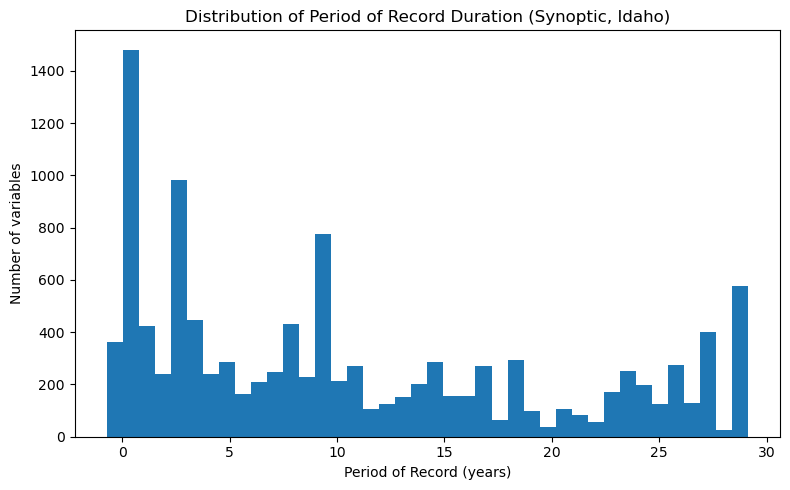

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df_var_enr["por_years"].dropna(), bins=40)
plt.xlabel("Period of Record (years)")
plt.ylabel("Number of variables")
plt.title("Distribution of Period of Record Duration (Synoptic, Idaho)")
plt.tight_layout()
plt.show()

In [8]:
df_var_enr = pd.read_csv(OUT_VAR_ENRICHED)
print("Variable rows:", len(df_var_enr))
df_var_enr[["variable_family","variable_native","sensor_height_m","period_of_record_json"]].head(100)

Variable rows: 11674


,variable_family,variable_native,sensor_height_m,period_of_record_json
0,air_temp,air_temp_1,NaN,"{""start"": ""2025-06-06T14:30:00Z"", ""end"": ""2026..."
1,relative_humidity,relative_humidity_1,NaN,"{""start"": ""2025-06-06T14:30:00Z"", ""end"": ""2026..."
2,wind_speed,wind_speed_1,NaN,"{""start"": ""2025-06-06T14:30:00Z"", ""end"": ""2026..."
3,wind_direction,wind_direction_1,NaN,"{""start"": ""2025-06-06T14:30:00Z"", ""end"": ""2026..."
4,wind_gust,wind_gust_1,NaN,"{""start"": ""2025-06-06T14:30:00Z"", ""end"": ""2026..."
...,...,...,...,...
95,wind_gust,wind_gust_1,NaN,"{""start"": ""2026-01-16T22:20:00Z"", ""end"": ""2026..."
96,volt,volt_1,NaN,"{""start"": ""2026-01-16T22:20:00Z"", ""end"": ""2026..."
97,air_temp,air_temp_1,NaN,"{""start"": ""2026-01-16T22:20:00Z"", ""end"": ""2026..."
98,dew_point_temperature,dew_point_temperature_1,NaN,"{""start"": ""2026-01-16T22:20:00Z"", ""end"": ""2026..."


In [9]:
print("Columns:", df_var_enr.columns.tolist())

print("\nNon-null % (key fields):")
for c in ["period_of_record_json","sensor_height_m","sensor_depth_m","position","dimension_json","unit"]:
    if c in df_var_enr.columns:
        print(c, ":", round(100*df_var_enr[c].notna().mean(), 2))

print("\nExample period_of_record_json values:")
print(df_var_enr["period_of_record_json"].dropna().head(5).tolist())

print("\nExample sensor_height_m values:")
print(df_var_enr["sensor_height_m"].dropna().head(10).tolist())

print("\nHow many variables have any POR JSON-like content (not {}, [], null)?")
s = df_var_enr["period_of_record_json"].astype("string")
por_present = s.notna() & (~s.str.strip().isin(["", "{}", "[]", "null", "None", "<NA>"]))
print(int(por_present.sum()), "of", len(df_var_enr), "(", round(100*por_present.mean(),2), "% )")

Columns: ['station_uid', 'source', 'source_station_id', 'network_id', 'variable_family', 'variable_native', 'unit', 'sensor_height_m', 'sensor_depth_m', 'position', 'dimension_json', 'period_of_record_json', 'source_details_json']

Non-null % (key fields):
period_of_record_json : 100.0
sensor_height_m : 0.0
sensor_depth_m : 0.0
position : 16.04
dimension_json : 100.0
unit : 0.0

Example period_of_record_json values:
['{"start": "2025-06-06T14:30:00Z", "end": "2026-02-17T18:10:00Z"}', '{"start": "2025-06-06T14:30:00Z", "end": "2026-02-17T18:10:00Z"}', '{"start": "2025-06-06T14:30:00Z", "end": "2026-02-17T18:10:00Z"}', '{"start": "2025-06-06T14:30:00Z", "end": "2026-02-17T18:10:00Z"}', '{"start": "2025-06-06T14:30:00Z", "end": "2026-02-17T18:10:00Z"}']

Example sensor_height_m values:
[]

How many variables have any POR JSON-like content (not {}, [], null)?
11674 of 11674 ( 100.0 % )


In [10]:
def observational_metadata_baseline_by_network(df_station_enr, df_var_enr):

    st = df_station_enr.copy()
    vr = df_var_enr.copy()

    st["network_id"] = st["network_id"].astype(str).str.strip()
    vr["network_id"] = vr["network_id"].astype(str).str.strip()

    rows = []

    for mnet_id, g_st in st.groupby("network_id"):
        n_st = int(g_st["station_uid"].nunique())
        g_vr = vr[vr["network_id"] == mnet_id]
        n_var = len(g_vr)

        # --- Station level ---
        provider_transparency = (
            (g_st["providers_json"].astype("string")
             .str.strip()
             .isin(["", "[]", "{}", "null", "None"]) == False).mean()
            if n_st else 0.0
        )

        siting_info = (
            (g_st["siting_json"].astype("string")
             .str.strip()
             .isin(["", "[]", "{}", "null", "None"]) == False).mean()
            if n_st else 0.0
        )

        # --- Variable level ---
        variable_inventory = 1.0 if n_var > 0 else 0.0

        period_of_record = (
            (g_vr["period_of_record_json"].astype("string")
             .str.strip()
             .isin(["", "[]", "{}", "null", "None"]) == False).mean()
            if n_var else 0.0
        )

        sensor_height = (
            g_vr["sensor_height_m"].notna().mean()
            if n_var else 0.0
        )

        # Synoptic API does not expose these consistently
        qaqc_info = 0.0
        network_policy = 0.0

        rows.append({
            "mnet_id": mnet_id,
            "n_stations": n_st,
            "variable_inventory_pct": round(100 * variable_inventory, 2),
            "period_of_record_pct": round(100 * period_of_record, 2),
            "sensor_height_pct": round(100 * sensor_height, 2),
            "qaqc_info_pct": round(100 * qaqc_info, 2),
            "siting_info_pct": round(100 * siting_info, 2),
            "provider_transparency_pct": round(100 * provider_transparency, 2),
            "network_policy_pct": round(100 * network_policy, 2),
        })

    out = pd.DataFrame(rows).sort_values("n_stations", ascending=False)
    out["generated_utc"] = pd.Timestamp.now("UTC").isoformat()
    return out

In [11]:
meta_obs = observational_metadata_baseline_by_network(df_station_enr, df_var_enr)
meta_obs.to_csv(OUT_BASELINE_BY_NET, index=False)
meta_obs.head(12)

,mnet_id,n_stations,variable_inventory_pct,period_of_record_pct,sensor_height_pct,qaqc_info_pct,siting_info_pct,provider_transparency_pct,network_policy_pct,generated_utc
9,2,156,100.0,100.0,0.0,0.0,0.0,96.15,0.0,2026-02-18T05:05:30.558949+00:00
25,41,129,100.0,100.0,0.0,0.0,0.0,100.00,0.0,2026-02-18T05:05:30.558949+00:00
10,204,116,100.0,100.0,0.0,0.0,0.0,0.00,0.0,2026-02-18T05:05:30.558949+00:00
17,3022,95,100.0,100.0,0.0,0.0,0.0,0.00,0.0,2026-02-18T05:05:30.558949+00:00
31,65,94,100.0,100.0,0.0,0.0,0.0,93.62,0.0,2026-02-18T05:05:30.558949+00:00
12,25,83,100.0,100.0,0.0,0.0,0.0,96.39,0.0,2026-02-18T05:05:30.558949+00:00
19,317,79,100.0,100.0,0.0,0.0,0.0,0.00,0.0,2026-02-18T05:05:30.558949+00:00
1,106,52,100.0,100.0,0.0,0.0,0.0,92.31,0.0,2026-02-18T05:05:30.558949+00:00
11,247,42,100.0,100.0,0.0,0.0,0.0,83.33,0.0,2026-02-18T05:05:30.558949+00:00
27,5,35,100.0,100.0,0.0,0.0,0.0,80.00,0.0,2026-02-18T05:05:30.558949+00:00


In [12]:
# -----------------------------
# Variable coverage by network
# -----------------------------

key_vars = {
    "air_temp": ["air_temp"],
    "precip": ["precip"],
    "wind": ["wind_speed", "wind_gust", "wind_dir"],
    "snow": ["snow_depth", "snow_water_equiv"],
    "radiation": ["solar_radiation", "shortwave", "radiation"],
    "soil": ["soil_temp", "soil_moisture"],
}

vr = df_var_enr.copy()
vr["network_id"] = vr["network_id"].astype(str)

rows = []

for net, g in vr.groupby("network_id"):
    rec = {"network_id": net}

    for label, families in key_vars.items():
        present = g["variable_family"].str.contains("|".join(families), case=False, na=False)
        rec[f"{label}_coverage_pct"] = round(100 * present.mean(), 2)

    rows.append(rec)

var_cov = pd.DataFrame(rows)
var_cov = var_cov.merge(
    meta_obs[["mnet_id","n_stations"]],
    left_on="network_id",
    right_on="mnet_id",
    how="left"
)

var_cov = var_cov.sort_values("n_stations", ascending=False)

var_cov.head(12)

,network_id,air_temp_coverage_pct,precip_coverage_pct,wind_coverage_pct,snow_coverage_pct,radiation_coverage_pct,soil_coverage_pct,mnet_id,n_stations
9,2,7.28,7.47,35.73,0.18,7.01,1.15,2,156
25,41,6.23,8.84,18.69,4.44,5.02,0.10,41,129
10,204,9.93,13.59,19.16,0.00,1.39,0.00,204,116
17,3022,11.11,11.11,33.33,0.00,11.11,0.00,3022,95
31,65,10.85,24.60,32.45,0.00,6.47,0.35,65,94
12,25,27.55,19.73,6.46,18.82,1.59,5.10,25,83
19,317,16.67,0.00,50.00,0.00,0.00,0.00,317,79
1,106,22.67,50.58,4.65,2.33,0.00,2.91,106,52
11,247,12.92,12.92,38.77,0.00,0.00,0.00,247,42
27,5,14.77,15.32,25.41,0.00,6.13,1.62,5,35


In [13]:
COVERAGE_CSV = os.path.join(OUT_DIR, "variable_coverage_by_network.csv")

var_cov.to_csv(COVERAGE_CSV, index=False)

print("[OUT]", COVERAGE_CSV, len(var_cov))

[OUT] out/variable_coverage_by_network.csv 41


In [14]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

coords = syn[["latitude","longitude"]].dropna().values

nn = NearestNeighbors(n_neighbors=2, metric="haversine")
nn.fit(np.radians(coords))

distances, _ = nn.kneighbors(np.radians(coords))
dist_km = distances[:,1] * 6371

print("Mean nearest-neighbor distance (km):", dist_km.mean())
print("95th percentile distance (km):", np.percentile(dist_km,95))

Mean nearest-neighbor distance (km): 4.760384752474536
95th percentile distance (km): 15.726581370137671


## Synoptic stations show strong clustering behavior, with a mean nearest-neighbor distance of ~4.8 km. However, the 95th percentile distance (~15.7 km) indicates that a non-negligible fraction of stations are spatially isolated, suggesting heterogeneous coverage

In [15]:
# -----------------------------
# Replace network_id with readable network name
# -----------------------------

net_meta = pd.read_csv("out/networks_in_idaho.csv")
net_meta["mnet_id"] = net_meta["mnet_id"].astype(str)

def build_label(row):
    sn = str(row.get("SHORTNAME", "")).strip()
    ln = str(row.get("LONGNAME", "")).strip()

    if sn and sn.lower() != "nan":
        return sn
    if ln and ln.lower() != "nan":
        return ln
    return f"MNET {row['mnet_id']}"

net_meta["network_label"] = net_meta.apply(build_label, axis=1)

id_to_label = dict(zip(net_meta["mnet_id"], net_meta["network_label"]))

# Apply mapping to var_cov (NOT df_plot)
var_cov["network_label"] = var_cov["network_id"].astype(str).map(id_to_label)

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

COVERAGE_CSV = "out/variable_coverage_by_network.csv"
NET_META_CSV = "out/networks_in_idaho.csv"

df = pd.read_csv(COVERAGE_CSV)
net = pd.read_csv(NET_META_CSV)

# --- normalize ids as strings (safe) ---
df["network_id"] = df["network_id"].astype(str).str.strip()
net["mnet_id"] = net["mnet_id"].astype(str).str.strip()

# --- build a nice label from Synoptic networks table ---
def build_label(row):
    sn = str(row.get("SHORTNAME", "")).strip()
    ln = str(row.get("LONGNAME", "")).strip()
    if sn and sn.lower() != "nan":
        return sn
    if ln and ln.lower() != "nan":
        return ln
    return f"MNET {row.get('mnet_id','')}"

net["network_label"] = net.apply(build_label, axis=1)

# --- merge labels into coverage table ---
df = df.merge(net[["mnet_id", "network_label"]], left_on="network_id", right_on="mnet_id", how="left")

# fallback if still missing labels
df["network_label"] = df["network_label"].fillna("MNET " + df["network_id"])

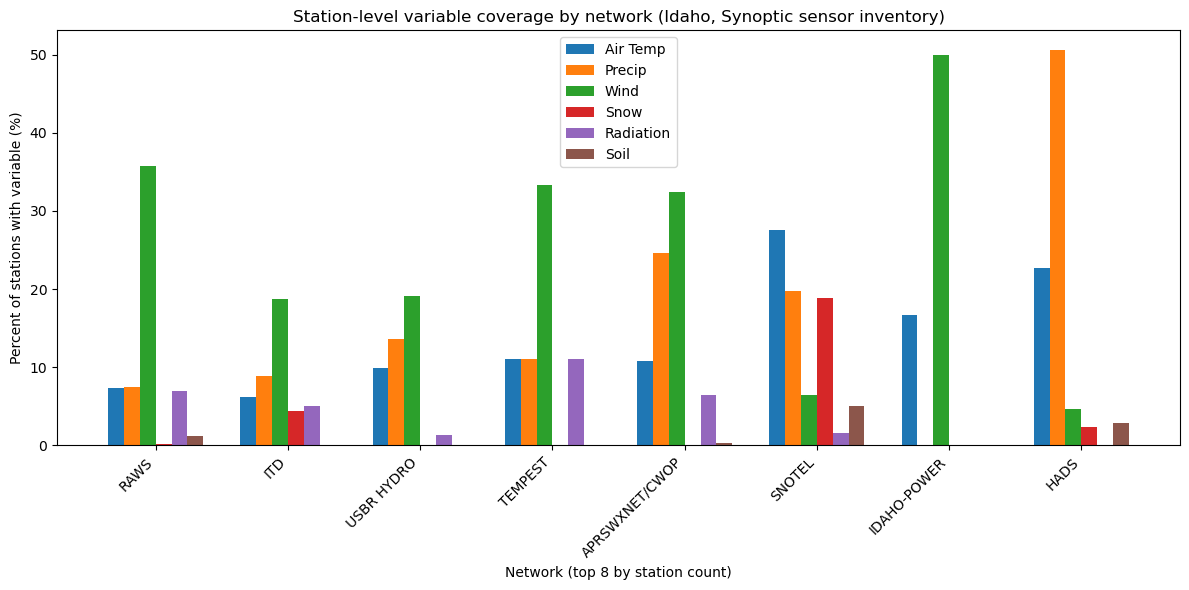

  network_id   network_label  n_stations
0          2            RAWS         156
1         41             ITD         129
2        204      USBR HYDRO         116
3       3022         TEMPEST          95
4         65  APRSWXNET/CWOP          94
5         25          SNOTEL          83
6        317     IDAHO-POWER          79
7        106            HADS          52


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

COVERAGE_CSV = "out/variable_coverage_by_network.csv"
NET_META_CSV = "out/networks_in_idaho.csv"

# --- Load ---
cov = pd.read_csv(COVERAGE_CSV)
net = pd.read_csv(NET_META_CSV)

# --- Normalize ids ---
# coverage table uses network_id; networks table uses mnet_id
cov["network_id"] = cov["network_id"].astype(str).str.strip()
net["mnet_id"] = net["mnet_id"].astype(str).str.strip()

# --- Build label from whatever columns exist ---
# (your file sometimes has network_shortname/network_name instead of SHORTNAME/LONGNAME)
def build_label(row):
    candidates = [
        row.get("SHORTNAME"),
        row.get("network_shortname"),
        row.get("LONGNAME"),
        row.get("network_name"),
        row.get("NAME"),
        row.get("name"),
    ]
    for c in candidates:
        if c is None:
            continue
        s = str(c).strip()
        if s and s.lower() != "nan":
            return s
    return f"MNET {row.get('mnet_id','')}"

net["network_label"] = net.apply(build_label, axis=1)

# --- Merge labels into coverage ---
df = cov.merge(net[["mnet_id", "network_label"]], left_on="network_id", right_on="mnet_id", how="left")

# Fallback if still missing
df["network_label"] = df["network_label"].fillna("MNET " + df["network_id"])

# --- Pick top N ---
df = df.sort_values("n_stations", ascending=False).head(8).copy()

variables = [
    "air_temp_coverage_pct",
    "precip_coverage_pct",
    "wind_coverage_pct",
    "snow_coverage_pct",
    "radiation_coverage_pct",
    "soil_coverage_pct",
]
labels = ["Air Temp", "Precip", "Wind", "Snow", "Radiation", "Soil"]

# --- Plot grouped bars centered under ticks ---
n_vars = len(variables)
x = np.arange(len(df))
width = 0.12
offset = (n_vars - 1) / 2 * width

plt.figure(figsize=(12,6))
for i, var in enumerate(variables):
    plt.bar(x + i*width - offset, df[var].values, width, label=labels[i])

plt.ylabel("Percent of stations with variable (%)")
plt.xlabel("Network (top 8 by station count)")
plt.title("Station-level variable coverage by network (Idaho, Synoptic sensor inventory)")
plt.xticks(x, df["network_label"].values, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

# --- sanity print ---
print(df[["network_id","network_label","n_stations"]].head(8))

# Station-Level Variable Coverage by Network (Idaho, Synoptic-based)

## Overview

This figure shows the **percentage of stations within each network** (top 8 networks by station count in Idaho) that report at least one sensor belonging to a given variable category, based on the **Synoptic `complete=1` metadata sensor inventory**.

---

## Networks Included

The x-axis displays `network_label`, a human-readable name derived from Synoptic network metadata.

| network_id | network_label |
|------------|--------------|
| 2          | RAWS |
| 41         | ITD |
| 204        | USBR HYDRO |
| 3022       | TEMPEST |
| 65         | APRSWXNET/CWOP |
| 25         | SNOTEL |
| 317        | IDAHO-POWER |
| 106        | HADS |

Only the **top 8 networks by number of stations in Idaho** are shown.

---

## Variable Categories

Variable coverage is determined using pattern matching on Synoptic `variable_family` metadata.

| Category    | Matched Variable Families |
|-------------|---------------------------|
| Air Temp    | `air_temp` |
| Precip      | `precip` |
| Wind        | `wind_speed`, `wind_gust`, `wind_dir` |
| Snow        | `snow_depth`, `snow_water_equiv` |
| Radiation   | `solar_radiation`, `shortwave`, `radiation` |
| Soil        | `soil_temp`, `soil_moisture` |

A station is counted if **at least one sensor family matches the category**.

---

## Methodology

For each `network_id`:

1. All Idaho stations belonging to that network were identified.
2. Synoptic API (`complete=1`, `sensorvars=1`) was used to retrieve full sensor metadata.
3. For each variable category:

\[
Coverage (\%) = \frac{\text{Stations with ≥1 matching sensor}}{\text{Total stations in network}} \times 100
\]

This is a **station-level presence metric**, not a sensor-count metric.

---

## What This Metric Represents

This figure approximates:

- Instrumentation breadth
- Observational capability diversity
- Variable-domain specialization by network
- Relative thematic focus (e.g., wind-oriented vs hydro-oriented networks)

It represents a **structural inventory snapshot**.

---

## Important Caveats

### 1️⃣ Synoptic-Mediated View

This analysis only includes:

- Stations federated through Synoptic
- Variables exposed via the Synoptic API

Stations not federated into Synoptic are not represented.

---

### 2️⃣ Variable Naming Sensitivity

Classification relies on string pattern matching of `variable_family`.

Potential blind spots:

- Alternative naming conventions
- Vendor-specific encodings
- Abbreviations not included in pattern list
- Variables embedded under custom dimensions

Thus, some categories may be slightly undercounted.

---

### 3️⃣ Presence ≠ Data Quality

This metric measures:

- Declared sensor inventory

It does **not** evaluate:

- Data continuity
- Gap frequency
- QA/QC procedures
- Calibration standards
- Measurement accuracy
- Maintenance practices

---

### 4️⃣ No Sensor Density Weighting

A station with:
- 1 wind sensor  
- 5 wind sensors  

Is counted equally as “wind present”.

Redundancy and vertical profiling are not captured.

---

### 5️⃣ No Temporal Stability Assessment

Although period-of-record metadata exists, this figure does not assess:

- Record length
- Continuity
- Gaps
- Stability over time

---

### 6️⃣ Soil and Radiation May Be Conservative

Certain soil or radiation sensors may be:

- Encoded under alternate variable families
- Embedded within non-standard metadata fields

Coverage may therefore be conservative for these domains.

---

## Interpretation

This figure should be interpreted as:

> A structural inventory snapshot of observational capability by network, based on declared sensor families within the Synoptic metadata framework.

It does **not** represent observational performance or reliability.

---

## Path Toward a Complete Observational System Assessment

To move beyond inventory toward system-level characterization, the following are required:

- Period-of-record length analysis (mean, median, variability)
- Temporal gap analysis
- QA/QC documentation mapping
- Sensor height consistency evaluation
- Spatial redundancy metrics
- Integration of non-Synoptic networks (e.g., direct SNOTEL, ITD exports)

---

This figure represents Phase 1 of an Idaho Hydrometeorological Observational System Assessment.